# Predicting used-car prices from Craigslist listings

**Team:** Mayuravarsha P, Vedant Mantri, Pranav Mekal Mahesh. Data Analytics, PES University (5th semester).
Revised analysis; the 2021 course notebook is kept as `original_used_cars.ipynb`.

**Data:** [Kaggle "Used Cars Dataset"](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data),
426,880 US Craigslist listings scraped in April–May 2021 (`data/vehicles.csv`, 1.4 GB, Git LFS). If the full file
isn't available, the notebook runs on the 30,000-row sample in `data/vehicles_sample.csv.gz`.

**Goal:** predict a listing's price from the car's attributes, and find out which attributes matter.

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from usedcars.data import read_raw, clean, CATEGORICAL, NUMERIC
from usedcars.experiment import run, split
from usedcars import models

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
FIG = "../figures/"
raw = read_raw()
print(f"{len(raw):,} raw listings")

426,880 raw listings


## 1. Why the raw data needs cleaning

In [2]:
pd.DataFrame({
    "price = $0": [(raw.price == 0).mean()],
    "price < $1,000": [(raw.price < 1000).mean()],
    "price > $150,000": [(raw.price > 150_000).mean()],
    "odometer > 400k": [(raw.odometer > 400_000).mean()],
    "VIN seen before": [raw.VIN.dropna().duplicated().sum() / len(raw)],
}).mul(100).round(2).rename(index={0: "% of listings"})

,price = $0,"price < $1,000","price > $150,000",odometer > 400k,VIN seen before
% of listings,7.71,10.85,0.05,0.4,34.57


In [3]:
print("most expensive 'cars':")
raw.nlargest(5, "price")[["price", "year", "manufacturer", "model"]]

most expensive 'cars':


,price,year,manufacturer,model
318592,3736928711,2007.0,toyota,tundra
356716,3736928711,1999.0,toyota,4runner
91576,3024942282,2000.0,mercedes-benz,benz e320
257840,3024942282,2000.0,mercedes-benz,benz s430
37410,3009548743,2021.0,chevrolet,NaN


* About **10 % of listings have a price under \$1,000**, mostly "\$0 — call for price" placeholders.
* A handful are nonsense (\$3.7 billion). A single one of these dominates squared-error metrics:
  it is why the original notebook's RMSE was \$88 million and its R² was −55.
* Dealers **re-post the same car** again and again. Without deduplication, the same vehicle ends up
  in both the training and the test set.

In [4]:
df = clean(raw)
print(f"{len(raw):,} -> {len(df):,} listings after cleaning")
df.describe().round(1)

426,880 -> 208,254 listings after cleaning


,price,age,odometer,cylinders
count,208254.0,208254.0,208254.0,134828.0
mean,15958.4,10.1,107584.6,5.8
std,13712.3,6.1,63550.3,1.6
min,1000.0,0.0,1.0,3.0
25%,6300.0,5.0,58572.2,4.0
50%,11989.0,9.0,104539.0,6.0
75%,21500.0,14.0,149604.0,8.0
max,150000.0,31.0,400000.0,12.0


## 2. What drives the price?

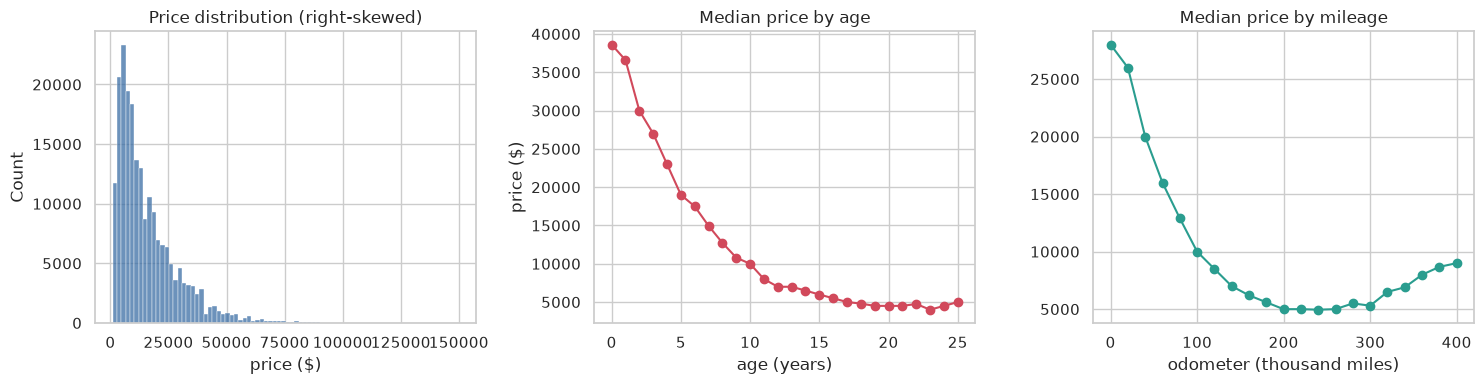

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df.price, bins=80, ax=axes[0], color="#3b6ea5")
axes[0].set(title="Price distribution (right-skewed)", xlabel="price ($)")
by_age = df[df.age <= 25].groupby("age").price.median()
axes[1].plot(by_age.index, by_age.values, marker="o", color="#d1495b")
axes[1].set(title="Median price by age", xlabel="age (years)", ylabel="price ($)")
odo = df.assign(bucket=(df.odometer // 20_000) * 20).groupby("bucket").price.median()
axes[2].plot(odo.index, odo.values, marker="o", color="#2a9d8f")
axes[2].set(title="Median price by mileage", xlabel="odometer (thousand miles)")
fig.tight_layout(); fig.savefig(FIG + "price_drivers.png", dpi=110)

In [6]:
age_fit = np.polyfit(df.loc[df.age.between(1, 15), "age"], np.log(df.loc[df.age.between(1, 15), "price"]), 1)
print(f"Cars lose about {100 * (1 - np.exp(age_fit[0])):.1f}% of their value per year of age (years 1-15, log-linear fit)")

Cars lose about 11.9% of their value per year of age (years 1-15, log-linear fit)


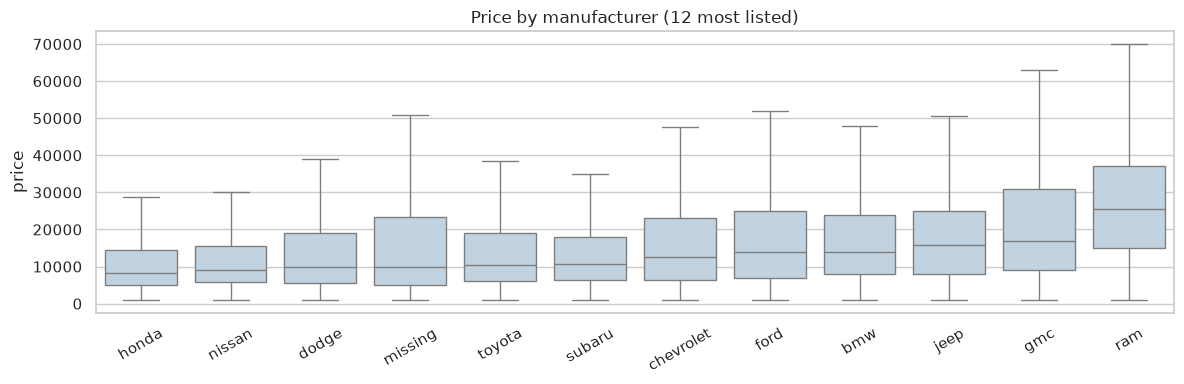

In [7]:
top = df.manufacturer.value_counts().index[:12]
fig, ax = plt.subplots(figsize=(12, 4))
order = df[df.manufacturer.isin(top)].groupby("manufacturer").price.median().sort_values().index
sns.boxplot(data=df[df.manufacturer.isin(top)], x="manufacturer", y="price", order=order,
            showfliers=False, ax=ax, color="#bcd4e6")
ax.set(title="Price by manufacturer (12 most listed)", xlabel="")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout(); fig.savefig(FIG + "price_by_make.png", dpi=110)

## 3. Models

All models predict **log(price)**. Price is right-skewed, and a relative error (10 % off) matters
more than an absolute one. Scores are reported on a held-out 20 % test set, both on the log scale and
back-transformed to dollars.

In [8]:
table, fitted, (X_train, X_test, y_train, y_test) = run(df)
table.style.format({"r2_log": "{:.3f}", "r2": "{:.3f}", "rmse": "${:,.0f}", "mae": "${:,.0f}",
                    "median_ape": "{:.1f}%", "train_seconds": "{:.1f}s"})

Baseline: median by make & year    R2(log)=0.565 MAE=$5,728


Ridge regression (one-hot)         R2(log)=0.781 MAE=$3,635


Random forest                      R2(log)=0.802 MAE=$3,372


Histogram gradient boosting        R2(log)=0.845 MAE=$2,952


LightGBM (native categoricals)     R2(log)=0.853 MAE=$2,716 (892 trees)


,r2_log,r2,rmse,mae,median_ape,train_seconds
model,,,,,,
LightGBM (native categoricals),0.853,0.845,"$5,382","$2,716",13.4%,18.7s
Histogram gradient boosting,0.845,0.830,"$5,637","$2,952",14.7%,6.1s
Random forest,0.802,0.778,"$6,446","$3,372",16.6%,5.5s
Ridge regression (one-hot),0.781,0.739,"$6,984","$3,635",17.1%,2.1s
Baseline: median by make & year,0.565,0.521,"$9,469","$5,728",30.2%,0.1s


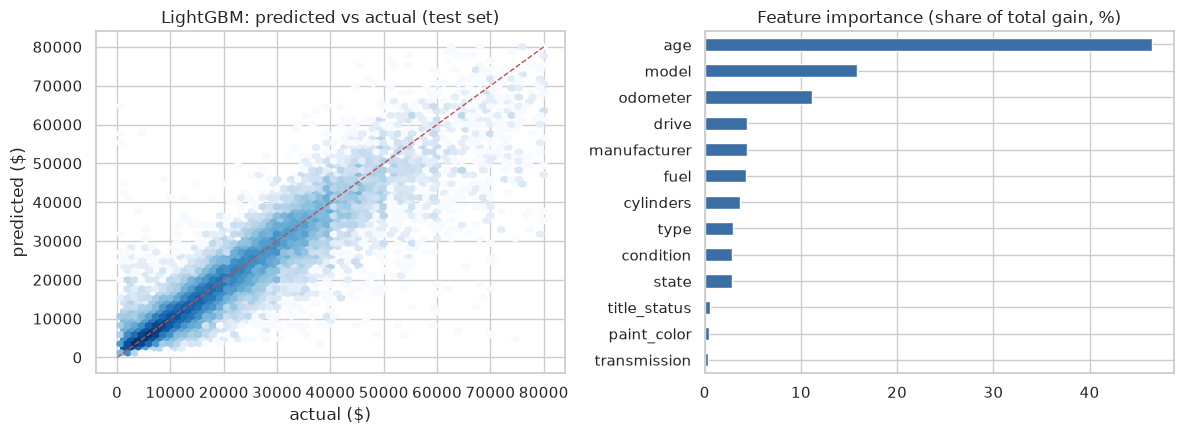

In [9]:
gbm, cats = fitted["LightGBM (native categoricals)"]
Xt, _ = models.as_lgb_frame(X_test, cats)
pred = np.exp(gbm.predict(Xt)); actual = np.exp(y_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hexbin(actual, pred, gridsize=60, bins="log", extent=(0, 80000, 0, 80000), cmap="Blues")
axes[0].plot([0, 80000], [0, 80000], "r--", lw=1)
axes[0].set(title="LightGBM: predicted vs actual (test set)", xlabel="actual ($)", ylabel="predicted ($)")
imp = pd.Series(gbm.booster_.feature_importance("gain"), index=gbm.feature_name_)
(imp / imp.sum() * 100).sort_values().plot.barh(ax=axes[1], color="#3b6ea5")
axes[1].set(title="Feature importance (share of total gain, %)", xlabel="")
fig.tight_layout(); fig.savefig(FIG + "lightgbm_results.png", dpi=110)

In [10]:
band = pd.cut(actual, [1000, 5000, 10000, 20000, 40000, 150000])
err = pd.DataFrame({"band": band, "ape": np.abs(pred - actual) / actual * 100})
err.groupby("band", observed=True).ape.agg(["count", "median"]).rename(
    columns={"median": "median % error"}).round(1)

,count,median % error
band,,
"(1000, 5000]",7338,23.0
"(5000, 10000]",11018,14.5
"(10000, 20000]",12061,11.9
"(20000, 40000]",8823,9.7
"(40000, 150000]",2255,12.8


**Results.** LightGBM with native categorical handling is best: **R² = 0.85 on log price**, with half of
all predictions within about **13 %** of the listed price. Age, model and odometer carry most of the
information. Errors are largest, in relative terms, for cheap cars (under \$5,000), where condition and
unrecorded damage matter most.

## 4. Two mistakes in the original notebook, demonstrated

### 4a. Duplicate listings leak between train and test

In [11]:
dup = raw[raw.price.between(1000, 150000) & raw.year.between(1990, 2022) & raw.odometer.between(1, 400000)].copy()
dup = clean(dup.assign(VIN=None).drop_duplicates(subset=["price", "year", "manufacturer", "model", "odometer", "state", "posting_date"]))
leaky, _, _ = run(dup, include_forest=False, verbose=False)
pd.DataFrame({"deduplicated by VIN": table.loc["LightGBM (native categoricals)", ["r2_log", "median_ape"]],
              "re-posts kept": leaky.loc["LightGBM (native categoricals)", ["r2_log", "median_ape"]]}).round(3)

,deduplicated by VIN,re-posts kept
r2_log,0.853,0.878
median_ape,13.394,11.296


Keeping re-posted cars makes the model look better than it is. It has partly *memorised* cars it
will then be tested on.

### 4b. The grid search chose the worst hyper-parameters

In [12]:
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

sub = df.sample(20000, random_state=0)
Xs, ys = sub[NUMERIC + CATEGORICAL], np.log(sub.price)
grid = {"decisiontreeregressor__max_depth": [2, 4, 8, 12, 16]}
pipe = make_pipeline(models._ordinal(), DecisionTreeRegressor(random_state=0))
wrong = GridSearchCV(pipe, grid, scoring=make_scorer(mean_squared_error), cv=3).fit(Xs, ys)
right = GridSearchCV(pipe, grid, scoring="neg_root_mean_squared_error", cv=3).fit(Xs, ys)
print("original scorer  -> best max_depth =", wrong.best_params_)
print("correct scorer   -> best max_depth =", right.best_params_)

original scorer  -> best max_depth = {'decisiontreeregressor__max_depth': 2}
correct scorer   -> best max_depth = {'decisiontreeregressor__max_depth': 8}


`make_scorer(mean_squared_error)` tells `GridSearchCV` that **higher error is better**, so it picks the
worst setting. The fix is `scoring="neg_root_mean_squared_error"` or `make_scorer(..., greater_is_better=False)`.

The original also used `StratifiedKFold` on a continuous price, which is meant for class labels, kept
only the last fold's split, and label-encoded 20,000 model names into one integer column.

## 5. Conclusions

* A cleaned, deduplicated dataset of about 208k listings supports a useful model: **median error ~13 %**
  of the price, R² 0.85 (log scale).
* **Age** is the strongest single factor (cars lose roughly 10–12 % of their value per year), followed by the
  **specific model** and **mileage**. Drive type, fuel and condition add smaller amounts.
* Gradient-boosted trees clearly beat linear regression and random forests here, largely because of the
  high-cardinality `model` feature.
* Next steps: use the free-text descriptions (trim level, damage, "salvage"), and add
  location-level effects and time-based validation.